Dataset Shape: (9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Catego

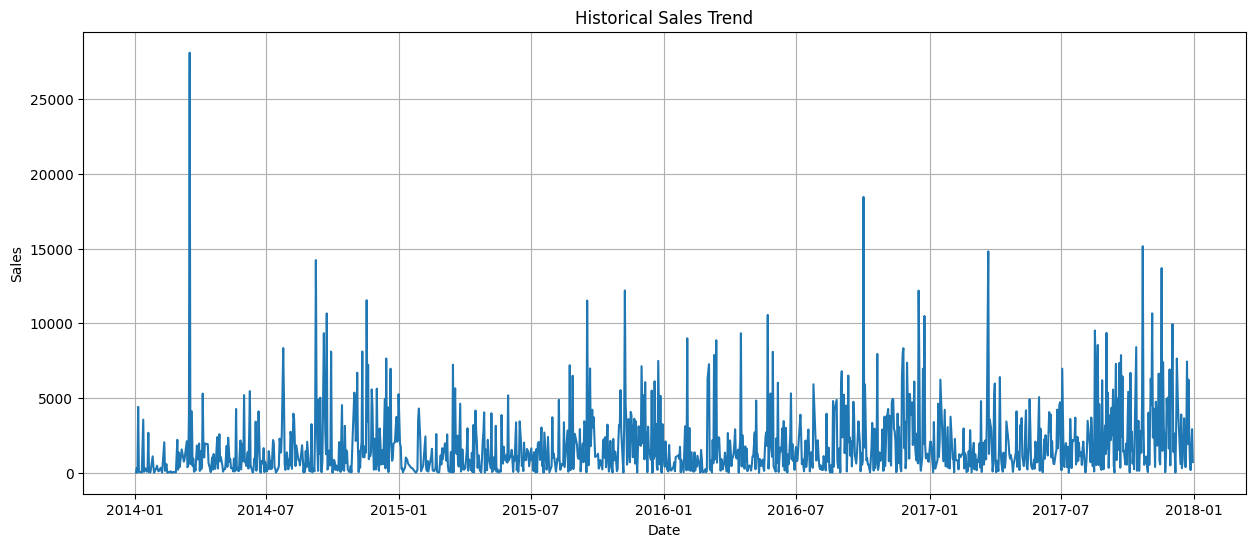


MODEL PERFORMANCE
-------------------
MAE : 1708.22
RMSE: 2507.17
R2  : -0.0267


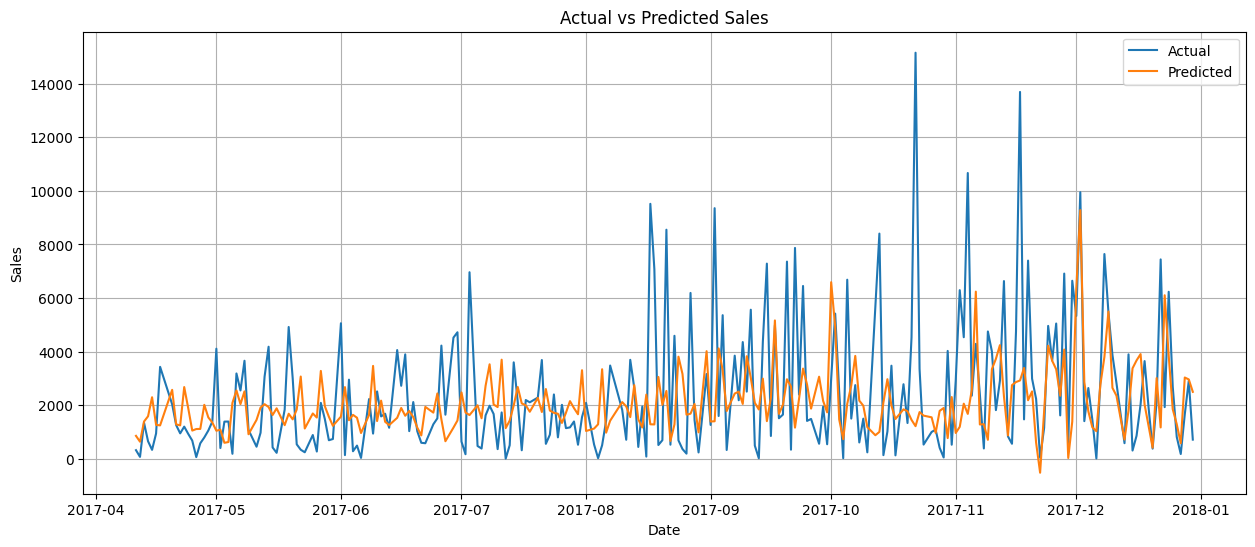


Feature Importance
            Feature  Importance
10  rolling_mean_30    0.156654
1             month    0.154342
2               day    0.103472
6             lag_1    0.101782
3         dayofweek    0.101678
7             lag_7    0.094882
8            lag_30    0.084029
9    rolling_mean_7    0.077381
5        weekofyear    0.070914
0              year    0.054864
4           quarter    0.000000


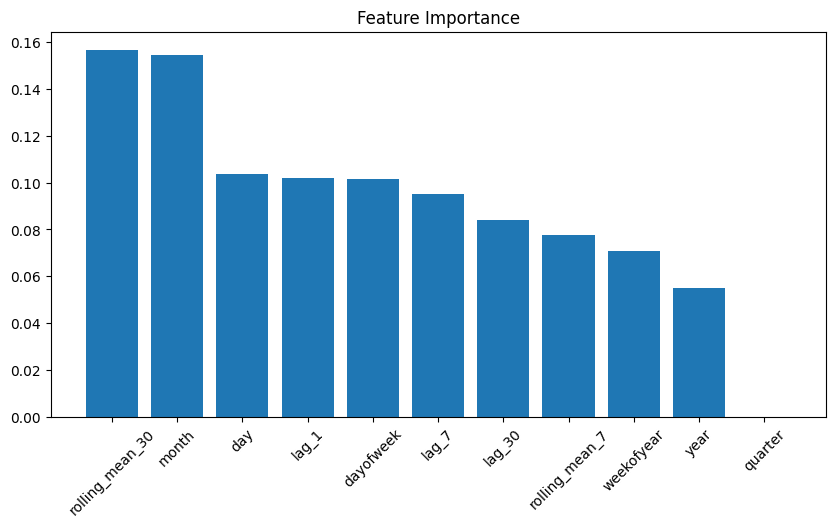

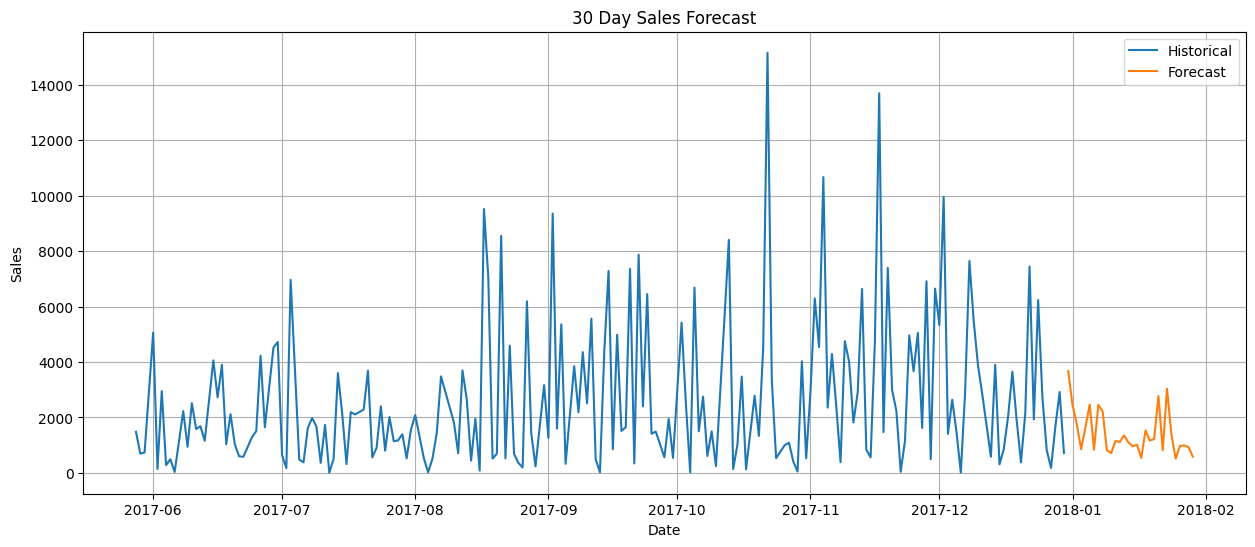


Forecast saved.

BUSINESS INSIGHTS
-------------------
Average Historical Sales: 3015.82
Average Forecast Sales: 1434.02
Expected Growth: -52.45%

Recommendation: Maintain conservative inventory planning.


In [2]:
# ==========================================
# SALES FORECASTING - SUPERSTORE DATASET
# ==========================================

!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(
    "/content/Sample - Superstore.csv",
    encoding="latin1"
)

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# CHECK COLUMNS
# ==========================================

print("\nColumns:")
print(df.columns.tolist())

# ==========================================
# CONVERT DATE COLUMN
# ==========================================

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
)

# ==========================================
# KEEP REQUIRED COLUMNS
# ==========================================

df = df[['Order Date','Sales']]

df.dropna(inplace=True)

# ==========================================
# DAILY SALES AGGREGATION
# ==========================================

daily_sales = (
    df.groupby('Order Date')['Sales']
      .sum()
      .reset_index()
)

daily_sales = daily_sales.sort_values(
    'Order Date'
)

# ==========================================
# HISTORICAL SALES VISUALIZATION
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales['Order Date'],
    daily_sales['Sales']
)

plt.title("Historical Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)
plt.show()

# ==========================================
# FEATURE ENGINEERING
# ==========================================

data = daily_sales.copy()

data['year'] = data['Order Date'].dt.year
data['month'] = data['Order Date'].dt.month
data['day'] = data['Order Date'].dt.day
data['dayofweek'] = data['Order Date'].dt.dayofweek
data['quarter'] = data['Order Date'].dt.quarter
data['weekofyear'] = (
    data['Order Date']
    .dt.isocalendar()
    .week
    .astype(int)
)

# Lag Features

data['lag_1'] = data['Sales'].shift(1)
data['lag_7'] = data['Sales'].shift(7)
data['lag_30'] = data['Sales'].shift(30)

# Rolling Mean

data['rolling_mean_7'] = (
    data['Sales']
    .shift(1)
    .rolling(7)
    .mean()
)

data['rolling_mean_30'] = (
    data['Sales']
    .shift(1)
    .rolling(30)
    .mean()
)

data.dropna(inplace=True)

# ==========================================
# FEATURES
# ==========================================

features = [
    'year',
    'month',
    'day',
    'dayofweek',
    'quarter',
    'weekofyear',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_mean_30'
]

X = data[features]
y = data['Sales']

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

split_index = int(
    len(data) * 0.8
)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

# ==========================================
# MODEL TRAINING
# ==========================================

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train,y_train)

# ==========================================
# PREDICTIONS
# ==========================================

predictions = model.predict(X_test)

# ==========================================
# EVALUATION
# ==========================================

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("\nMODEL PERFORMANCE")
print("-------------------")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2  :", round(r2,4))

# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

results = pd.DataFrame({
    'Date':
    data.iloc[split_index:]['Order Date'],

    'Actual':
    y_test.values,

    'Predicted':
    predictions
})

plt.figure(figsize=(15,6))

plt.plot(
    results['Date'],
    results['Actual'],
    label='Actual'
)

plt.plot(
    results['Date'],
    results['Predicted'],
    label='Predicted'
)

plt.title(
    "Actual vs Predicted Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    'Feature': features,
    'Importance':
    model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance)

plt.figure(figsize=(10,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=45)

plt.title(
    "Feature Importance"
)

plt.show()

# ==========================================
# FUTURE FORECAST
# ==========================================

future_days = 30

future_dates = pd.date_range(
    start=
    data['Order Date'].max()
    +
    pd.Timedelta(days=1),

    periods=future_days
)

last_sales = list(
    data['Sales'].tail(30)
)

future_predictions = []

for date in future_dates:

    future_row = pd.DataFrame({

        'year':[date.year],
        'month':[date.month],
        'day':[date.day],
        'dayofweek':[date.dayofweek],
        'quarter':[date.quarter],
        'weekofyear':[date.isocalendar().week],

        'lag_1':[last_sales[-1]],
        'lag_7':[last_sales[-7]],
        'lag_30':[last_sales[-30]],

        'rolling_mean_7':
        [np.mean(last_sales[-7:])],

        'rolling_mean_30':
        [np.mean(last_sales[-30:])]
    })

    pred = model.predict(
        future_row
    )[0]

    future_predictions.append(pred)

    last_sales.append(pred)

forecast_df = pd.DataFrame({
    'Date':future_dates,
    'Forecasted_Sales':
    future_predictions
})

# ==========================================
# FORECAST VISUALIZATION
# ==========================================

plt.figure(figsize=(15,6))

plt.plot(
    data['Order Date'].tail(200),
    data['Sales'].tail(200),
    label='Historical'
)

plt.plot(
    forecast_df['Date'],
    forecast_df['Forecasted_Sales'],
    label='Forecast'
)

plt.title(
    "30 Day Sales Forecast"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# SAVE FORECAST
# ==========================================

forecast_df.to_csv(
    "sales_forecast.csv",
    index=False
)

print("\nForecast saved.")

# ==========================================
# BUSINESS INSIGHTS
# ==========================================

historical_avg = (
    data['Sales']
    .tail(30)
    .mean()
)

future_avg = (
    forecast_df[
        'Forecasted_Sales'
    ].mean()
)

growth = (
    (
        future_avg -
        historical_avg
    )
    /
    historical_avg
) * 100

print("\nBUSINESS INSIGHTS")
print("-------------------")

print(
    f"Average Historical Sales: {historical_avg:.2f}"
)

print(
    f"Average Forecast Sales: {future_avg:.2f}"
)

print(
    f"Expected Growth: {growth:.2f}%"
)

if growth > 0:
    print(
        "\nRecommendation: Increase inventory levels and prepare for higher demand."
    )
else:
    print(
        "\nRecommendation: Maintain conservative inventory planning."
    )